# Análises COVID-19

Vamos analisar a contaminação do vírus COVID-19 pelo mundo.

In [125]:
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

In [126]:
url = 'https://github.com/neylsoncrepalde/projeto_eda_covid/blob/master/covid_19_data.csv?raw=true'
df = pd.read_csv(url, parse_dates=['ObservationDate', 'Last Update'])

# Converter a coluna 'ObservationDate' para datetime
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

# Exibir as primeiras linhas para verificar a estrutura dos dados
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,2020-01-22,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,2020-01-22,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,2020-01-22,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,2020-01-22,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,2020-01-22,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


### Tratamento de valores ausentes

In [128]:
# Verificar valores ausentes
df.isnull().sum()

# Preencher valores ausentes (por exemplo, usando a mediana para variáveis numéricas)
df['Confirmed'] = df['Confirmed'].fillna(df['Confirmed'].median())
df['Deaths'] = df['Deaths'].fillna(df['Deaths'].median())
df['Recovered'] = df['Recovered'].fillna(df['Recovered'].median())


#### Verificando Informaçõpes Básicas

##### Analisando as Variáveis Categóricas como Country/Region e Province/State

In [131]:
# Verificar a contagem de valores para variáveis categóricas
print(df['Country/Region'].value_counts())
print(df['Province/State'].value_counts())


Country/Region
US                     4990
Mainland China         3687
Canada                 1093
Australia               788
France                  752
                       ... 
North Ireland             1
Channel Islands           1
Cape Verde                1
Republic of Ireland       1
East Timor                1
Name: count, Length: 223, dtype: int64
Province/State
Diamond Princess cruise ship    175
Grand Princess                  132
Hebei                           121
Gansu                           121
Shanxi                          119
                               ... 
Queens County, NY                 1
Fench Guiana                      1
Shasta County, CA                 1
Norwell County, MA                1
Spartanburg County, SC            1
Name: count, Length: 353, dtype: int64


#### Análise de Tendências Temporais

##### Agora vamos poder ver como os casos de COVID-19 se espalham ao longo do tempo.

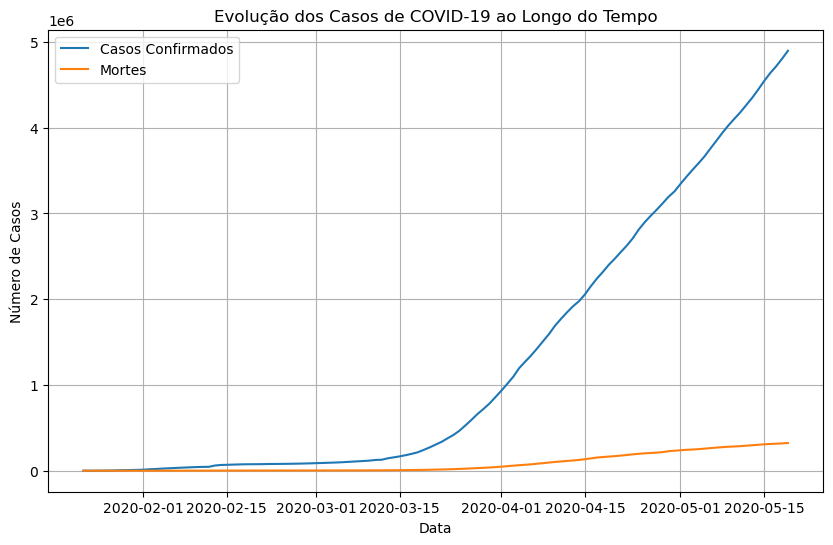

In [134]:
# Converter a coluna 'ObservationDate' para datetime
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

# Agregar os dados por data para ver a evolução dos casos globalmente
df_time_series = df.groupby('ObservationDate').sum()

# Plotar o número total de casos confirmados ao longo do tempo
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.plot(df_time_series.index, df_time_series['Confirmed'], label='Casos Confirmados')
plt.plot(df_time_series.index, df_time_series['Deaths'], label='Mortes')
plt.title('Evolução dos Casos de COVID-19 ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()


#### Análise de Casos por País

##### Visualização dos dados de casos confirmados, mortes, recuperados

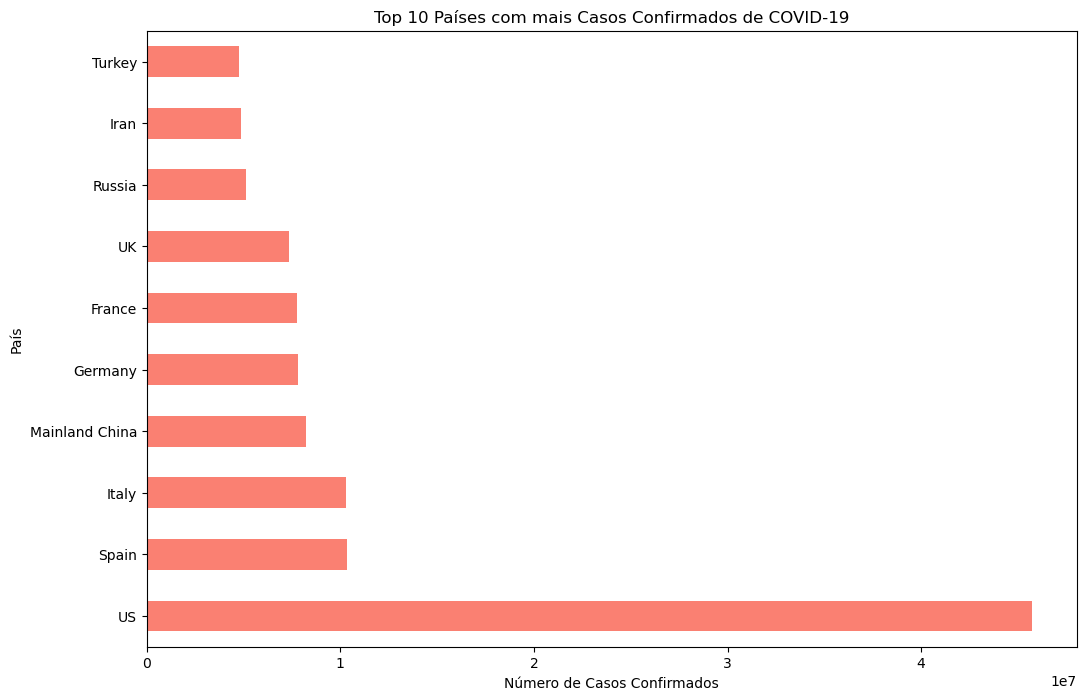

In [137]:
# Casos totais por país
df_country = df.groupby('Country/Region').sum(numeric_only=True)

# Plotar os 10 países com mais casos confirmados
plt.figure(figsize=(12, 8))
df_country.sort_values('Confirmed', ascending=False).head(10)['Confirmed'].plot(kind='barh', color='salmon')
plt.title('Top 10 Países com mais Casos Confirmados de COVID-19')
plt.xlabel('Número de Casos Confirmados')
plt.ylabel('País')
plt.show()


#### Taxa de Mortalidade (Death Rate)

##### Para calcular a taxa de mortalidade, dividindo o número de mortes pelo número de casos confirmados e multiplicando por 100 para obter uma porcentagem.

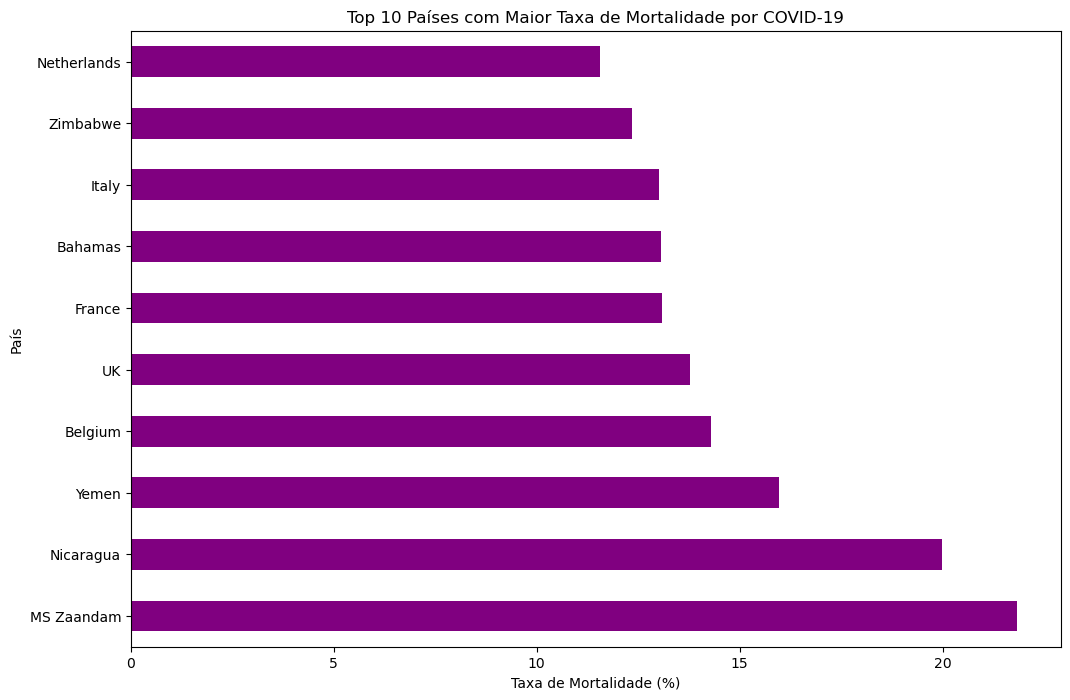

In [140]:
# Calcular taxa de mortalidade por país
df_country['DeathRate'] = df_country['Deaths'] / df_country['Confirmed'] * 100

# Plotar os 10 países com maior taxa de mortalidade
plt.figure(figsize=(12, 8))
df_country.sort_values('DeathRate', ascending=False).head(10)['DeathRate'].plot(kind='barh', color='purple')
plt.title('Top 10 Países com Maior Taxa de Mortalidade por COVID-19')
plt.xlabel('Taxa de Mortalidade (%)')
plt.ylabel('País')
plt.show()

#### Análise de Casos Ativos

##### Casos confirmados menos os casos de mortes e recuperados.

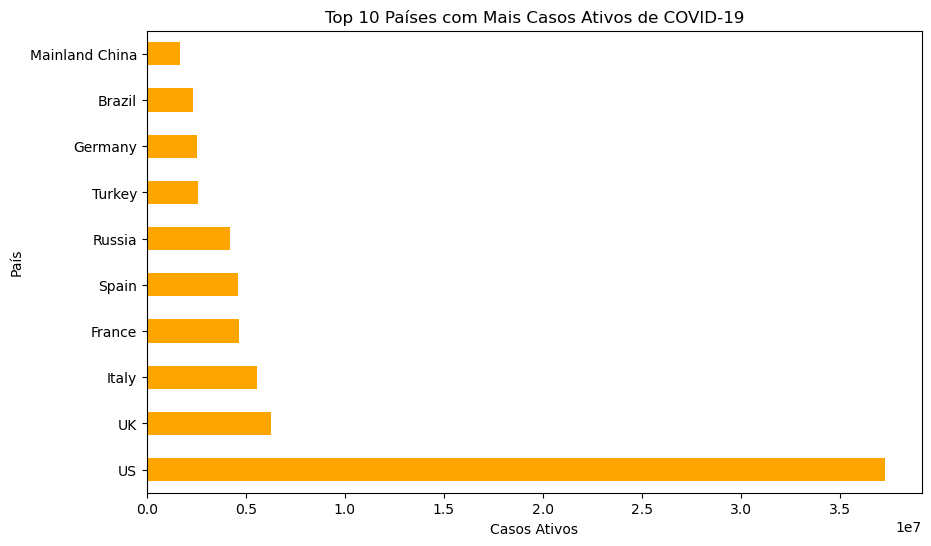

In [143]:
# Calcular casos ativos
df_country['Active'] = df_country['Confirmed'] - df_country['Deaths'] - df_country['Recovered']

# Plotar a evolução dos casos ativos ao longo do tempo
plt.figure(figsize=(10, 6))
df_country.sort_values('Active', ascending=False).head(10)['Active'].plot(kind='barh', color='orange')
plt.title('Top 10 Países com Mais Casos Ativos de COVID-19')
plt.xlabel('Casos Ativos')
plt.ylabel('País')
plt.show()


### Casos por Continente 

<Axes: xlabel='Continent'>

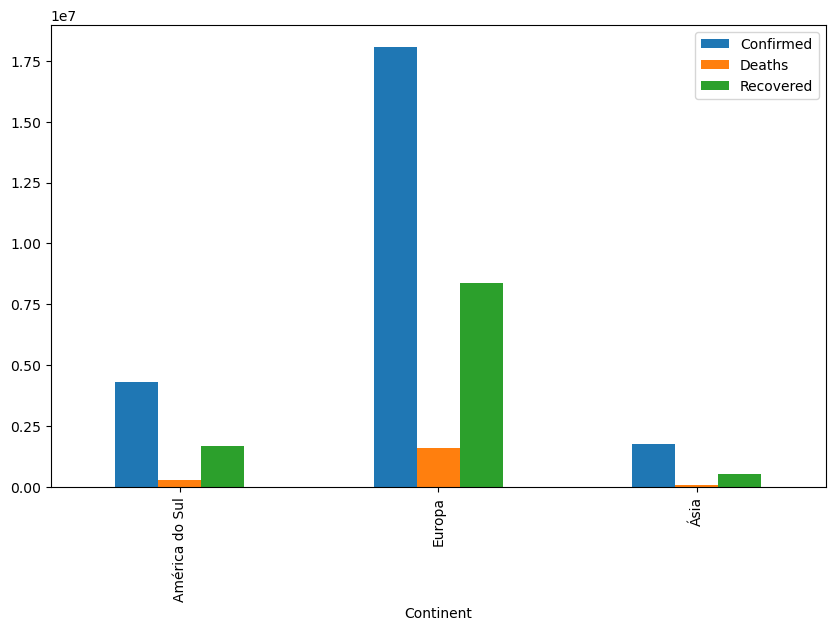

In [145]:
continente_dict = {
    'China': 'Ásia', 'Italy': 'Europa', 'USA': 'América do Norte', 
    'Brazil': 'América do Sul', 'India': 'Ásia', 'Germany': 'Europa'
    # Adicione o resto dos países e seus continentes aqui...
}
df['Continent'] = df['Country/Region'].map(continente_dict)
df_continent = df.groupby('Continent').sum(numeric_only=True)
df_continent[['Confirmed', 'Deaths', 'Recovered']].plot(kind='bar', figsize=(10, 6))


#### Taxa de mortalidade Global

In [160]:
# Calcular a taxa global de mortalidade
total_deaths = df['Deaths'].sum()
total_confirmed = df['Confirmed'].sum()

mortality_rate_global = (total_deaths / total_confirmed) * 100
print(f"Taxa de Mortalidade Global: {mortality_rate_global:.2f}%")


Taxa de Mortalidade Global: 6.56%
